In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import joblib
import pyodbc
import matplotlib.pyplot as plt

import warnings
from sqlalchemy.exc import SAWarning
from sqlalchemy import create_engine, text

ModuleNotFoundError: No module named 'torch'

In [4]:
# =========================
# 설정
# =========================
warnings.filterwarnings("ignore", category=SAWarning)

COL = "F10_01"
SEQ_LEN = 20
MODEL_DIR = f"./model/{COL}"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# =========================
# 1. 모델 로드
# =========================
class LSTMAutoencoder(nn.Module):
    def __init__(self, seq_len, n_features, embedding_dim=64):
        super().__init__()
        
        self.seq_len = seq_len
        
        self.encoder = nn.LSTM(
            n_features, embedding_dim,
            num_layers=2, batch_first=True, dropout=0.2
        )
        
        self.decoder = nn.LSTM(
            embedding_dim, embedding_dim,
            num_layers=2, batch_first=True, dropout=0.2
        )
        
        self.output_layer = nn.Linear(embedding_dim, n_features)
    
    def forward(self, x):
        _, (hidden, _) = self.encoder(x)
        hidden = hidden[-1]
        
        hidden = hidden.unsqueeze(1).repeat(1, self.seq_len, 1)
        
        decoded, _ = self.decoder(hidden)
        out = torch.sigmoid(self.output_layer(decoded))
        
        return out


model = LSTMAutoencoder(SEQ_LEN, 1).to(device)
state_dict = torch.load(
    f"{MODEL_DIR}/model.pth",
    map_location=device,
    weights_only=True  # 🔥 추가
)
model.load_state_dict(state_dict)
model.eval()

scaler = joblib.load(f"{MODEL_DIR}/scaler.pkl")
threshold = np.load(f"{MODEL_DIR}/threshold.npy")

print("모델 로드 완료")

모델 로드 완료


In [7]:
# =========================
# 2. DB 로드
# =========================
def load_data():
    server = "127.0.0.1"
    database = "kamtec"
    username = "sa"
    password = "1234"
    driver = "ODBC Driver 18 for SQL Server"

    params = urllib.parse.quote_plus(
        f"DRIVER={driver};SERVER={server};DATABASE={database};UID={username};PWD={password};Encrypt=no;TrustServerCertificate=yes;"
    )

    engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

    query = f"""
        SELECT s001, {COL}
        FROM lmsCurrent WITH (NOLOCK)
        WHERE {COL} IS NOT NULL AND {COL} > 0
        ORDER BY id DESC
    """

    with engine.connect() as conn:
        df = pd.read_sql(text(query), conn)

    df = df.sort_values("s001")  # 시간순 정렬
    return df

df = load_data()
print("데이터 로드 성공! 총 데이터 수:", len(df))

데이터 로드 성공! 총 데이터 수: 85568019


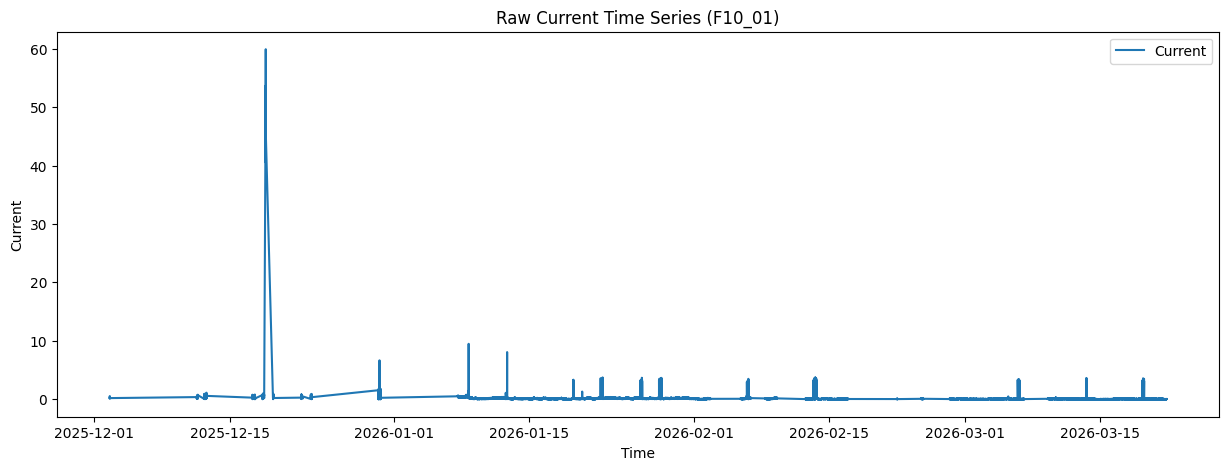

In [8]:
# ==========================================
# 1-1. 전체 데이터 시각화
# ==========================================
plt.figure(figsize=(15, 5))

plt.plot(df["s001"], df[COL], label="Current")

plt.title(f"Raw Current Time Series ({COL})")
plt.xlabel("Time")
plt.ylabel("Current")
plt.legend()

plt.show()

In [9]:
# =========================
# 3. 스케일링
# =========================
df["scaled"] = scaler.transform(df[[COL]])

signal = df["scaled"].values

In [10]:
# =========================
# 4. 스파이크 추출 (학습과 동일)
# =========================
def extract_rising_start_sequences(
    signal,
    seq_len=20,
    pre_offset=4,
    slope_factor=3.0,
    min_peak=0.4
):
    signal = np.asarray(signal)
    diff = np.diff(signal)

    slope_th = diff.mean() + slope_factor * diff.std()

    rising_points = np.where(
        (diff[:-2] <= 0) &
        (diff[1:-1] > slope_th) &
        (diff[2:] > 0)
    )[0] + 1

    sequences = []
    indices = []  # 🔥 위치 저장 (중요)

    last_idx = -seq_len

    for i in rising_points:
        if i - last_idx < seq_len:
            continue

        start = i - pre_offset
        end = start + seq_len

        if start < 0 or end > len(signal):
            continue

        seq = signal[start:end]

        if seq.max() < min_peak:
            continue

        seq_diff = diff[start:end-1]
        if seq_diff.max() <= 0.15:
            continue

        peak_idx = np.argmax(seq)
        if not (pre_offset <= peak_idx <= pre_offset + 6):
            continue

        sequences.append(seq)
        indices.append(start)  # 🔥 원본 위치 기록

        last_idx = i

    return np.array(sequences), np.array(indices)


sequences, indices = extract_rising_start_sequences(signal)

print("추출된 스파이크:", len(sequences))

if len(sequences) == 0:
    print("스파이크 없음")
    exit()

추출된 스파이크: 40


In [11]:
# =========================
# 5. 추론
# =========================
X = torch.tensor(sequences, dtype=torch.float32).unsqueeze(-1).to(device)

with torch.no_grad():
    output = model(X)

In [12]:
# =========================
# 6. 에러 계산
# =========================
errors = torch.mean((X - output) ** 2, dim=(1,2)).cpu().numpy()

anomalies = errors > threshold

print("이상 개수:", np.sum(anomalies))

이상 개수: 7


In [13]:
# =========================
# 7. 결과 출력
# =========================
anomaly_indices = indices[anomalies]

for i, idx in enumerate(anomaly_indices[:10]):
    print(f"🚨 이상 발생 위치 index={idx}, time={df.iloc[idx]['s001']}, error={errors[anomalies][i]}")

🚨 이상 발생 위치 index=1545, time=2025-12-18 17:32:28.278846, error=178.7524871826172
🚨 이상 발생 위치 index=948491, time=2026-01-08 17:03:14.616000, error=0.2123764604330063
🚨 이상 발생 위치 index=948556, time=2026-01-08 17:03:21.130000, error=0.1370355635881424
🚨 이상 발생 위치 index=952988, time=2026-01-08 17:10:46.613000, error=0.2830449044704437
🚨 이상 발생 위치 index=31338731, time=2026-01-28 14:10:53.173000, error=0.04514189809560776
🚨 이상 발생 위치 index=31398895, time=2026-01-28 15:02:07.688000, error=0.045292798429727554
🚨 이상 발생 위치 index=45511572, time=2026-02-13 11:28:33.562000, error=0.06720031797885895


In [21]:
def plot_each_anomaly_with_time(model, sequences, errors, anomalies, scaler, indices, df, device):
    model.eval()
    
    anomaly_idx = np.where(anomalies)[0]
    
    for i, idx in enumerate(anomaly_idx):
        seq = sequences[idx]
        
        input_tensor = torch.tensor(seq, dtype=torch.float32)\
                            .unsqueeze(0).unsqueeze(-1).to(device)
        
        with torch.no_grad():
            output = model(input_tensor)
        
        input_np = input_tensor.squeeze().cpu().numpy()
        output_np = output.squeeze().cpu().numpy()
        
        input_raw = scaler.inverse_transform(input_np.reshape(-1,1)).flatten()
        output_raw = scaler.inverse_transform(output_np.reshape(-1,1)).flatten()
        
        time_str = df.iloc[indices[idx]]["s001"]
        
        plt.figure(figsize=(8, 4))
        plt.plot(input_raw, marker='o', label="Original")
        plt.plot(output_raw, linestyle='--', label="Reconstructed")
        
        plt.title(f"{time_str} | error={errors[idx]:.4f}")
        plt.legend()
        plt.show()

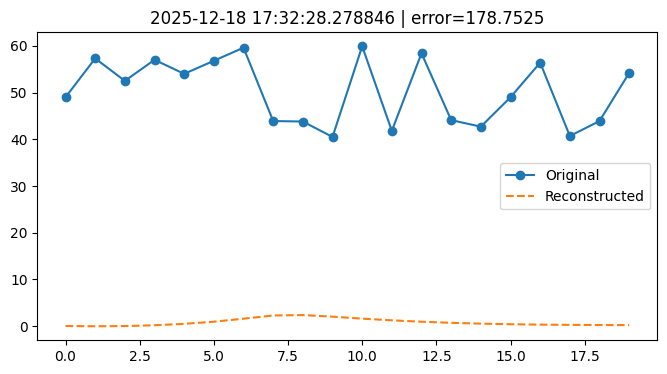

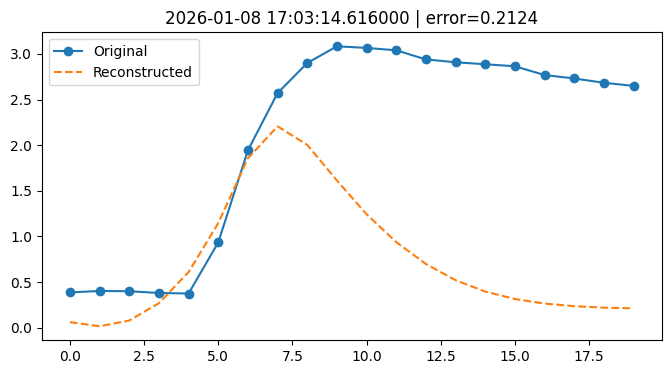

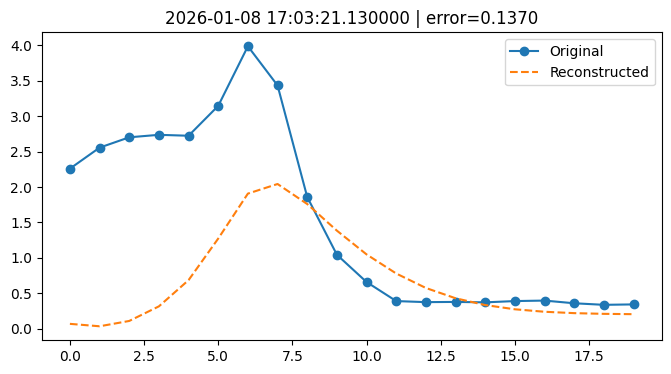

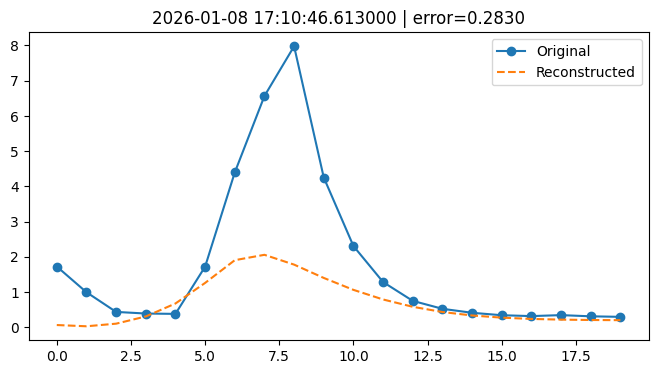

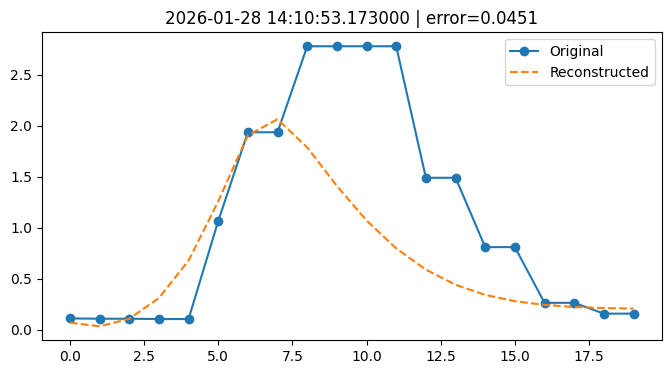

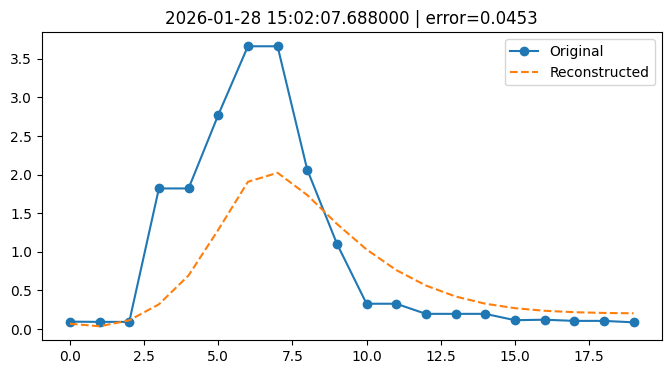

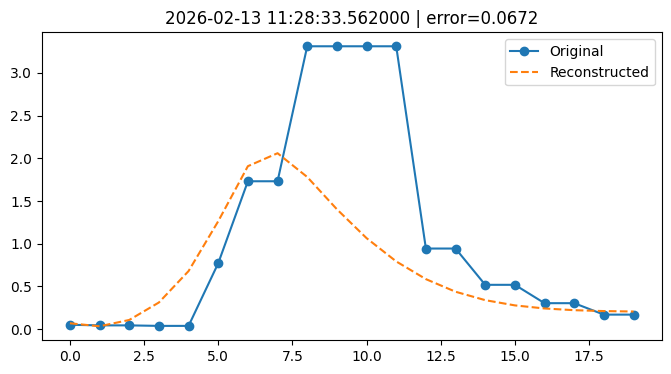

In [22]:
plot_each_anomaly_with_time(
    model=model,
    sequences=sequences,
    errors=errors,
    anomalies=anomalies,
    scaler=scaler,
    indices=indices,
    df=df,
    device=device
)